# Trabalho Final - notebook base do projeto da Giovanna

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Pergunta de pesquisa

#### **Quais fatores parecem ter maior relação com o sucesso profissional dos estudantes?**

(GPA, networking, soft skills, certificações)

--- O sucesso profissional de recém-formados costuma ser associado a características desenvolvidas ao longo da formação acadêmica: desempenho acadêmico, construção de rede de contatos, habilidades interpessoais e qualificações complementares. Neste trabalho será utilizado o conjunto de dados *Education and Career Success*, que reúne informações de 400 estudantes sobre seu histórico acadêmico e o início de sua trajetória profissional. Pretende-se avaliar como o GPA universitário, a pontuação de networking, a pontuação de soft skills e o número de certificações se relacionam com indicadores de sucesso profissional (propostas de emprego recebidas, salário inicial e satisfação com a carreira) — sem supor de antemão qual desses quatro fatores está mais associado ao sucesso, já que eles podem estar correlacionados entre si.

In [2]:
# Carrega o dataset de educação e sucesso profissional e mostra as primeiras linhas
df = pd.read_csv("../datasets/giovanna/education_career_success.zip", compression='zip')

df.head()

,Student_ID,Age,Gender,High_School_GPA,SAT_Score,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
0,S001,22,Male,3.8,1450,3.6,Computer Science,3,7,2,8,7,3,85000,8,2,Mid,7,No
1,S002,24,Female,3.6,1380,3.4,Business,2,5,3,7,6,2,65000,7,3,Mid,6,No
2,S003,21,Male,3.9,1520,3.8,Engineering,4,9,4,9,8,4,120000,9,1,Senior,6,No
3,S004,23,Female,3.5,1300,3.2,Psychology,1,3,1,6,5,1,48000,6,4,Entry,8,No
4,S005,25,Male,3.7,1420,3.5,Medicine,2,6,2,8,7,3,95000,8,2,Mid,5,No


In [3]:
# Lista todas as colunas disponíveis, para localizar as variáveis da pergunta de pesquisa
df.columns

Index(['Student_ID', 'Age', 'Gender', 'High_School_GPA', 'SAT_Score',
       'University_GPA', 'Field_of_Study', 'Internships_Completed',
       'Projects_Completed', 'Certifications', 'Soft_Skills_Score',
       'Networking_Score', 'Job_Offers', 'Starting_Salary',
       'Career_Satisfaction', 'Years_to_Promotion', 'Current_Job_Level',
       'Work_Life_Balance', 'Entrepreneurship'],
      dtype='str')

## Classificação das variáveis associadas à pergunta de pesquisa

A pergunta de pesquisa cita quatro fatores (GPA, networking, soft skills, certificações), mas pede a relação deles com o **sucesso profissional**, que é um conceito, não uma coluna do dataset. Para poder medir essa relação, usamos três colunas do próprio dataset que operacionalizam sucesso profissional de forma direta e sem precisar combinar ou transformar nada: `Job_Offers` (quantidade de propostas de emprego recebidas), `Starting_Salary` (salário inicial) e `Career_Satisfaction` (satisfação autorreferida com a carreira). Juntas, elas cobrem tanto indicadores objetivos de sucesso (propostas recebidas, salário) quanto um indicador subjetivo (satisfação). Essa escolha é declarada aqui de forma explícita: "sucesso profissional" em si não existe como coluna no dataset, e essas três colunas são usadas como proxies diretos e plausíveis dele — não a variável original, que não existe.

A coluna `Entrepreneurship` **não** é usada como variável de análise: ela tem um único valor (`No`) para todos os 400 estudantes, ou seja, não varia, e por isso não serve para diferenciar grupos nem para responder à pergunta de pesquisa.

In [4]:
df["University_GPA"].unique()

array([3.6, 3.4, 3.8, 3.2, 3.5, 3.1, 2.9, 3.7, 3.3, 3.9, 3. , 2.8, 4. ])

O GPA universitário é uma variável **numérica** e varia de 2.8 a 4.0 no dataset (escala usual de 0 a 4.0 usada em universidades norte-americanas).

In [5]:
df["Networking_Score"].unique()

array([7, 6, 8, 5, 4, 9])

A pontuação de networking é uma variável **numérica** e varia de 4 a 9 no dataset. O arquivo não informa a escala original desse escore; é razoável supor (hipótese, não confirmada no arquivo) que a escala completa vá de 0 a 10, já que esse é o intervalo mais comum para pontuações desse tipo e o intervalo observado cabe inteiramente dentro dele — mas o que sabemos com certeza é apenas o intervalo de 4 a 9 realmente registrado.

In [6]:
df["Soft_Skills_Score"].unique()

array([ 8,  7,  9,  6, 10,  5])

A pontuação de soft skills é uma variável **numérica** e varia de 5 a 10 no dataset. Pela mesma razão do Networking Score, é razoável supor (hipótese) que a escala completa seja de 0 a 10, mas isso não é confirmado no arquivo — o dado certo é o intervalo de 5 a 10 observado.

In [7]:
df["Certifications"].unique()

array([2, 3, 4, 1, 0, 5])

O número de certificações é uma variável **numérica** (contagem) e varia de 0 a 5 no dataset.

In [8]:
df["Job_Offers"].unique()

array([3, 2, 4, 1, 0, 5])

O número de propostas de emprego recebidas é uma variável **numérica** (contagem) e varia de 0 a 5 no dataset.

In [9]:
df["Starting_Salary"].unique()

array([ 85000,  65000, 120000,  48000,  95000,  42000,  35000, 110000,
        72000, 140000,  40000,  68000,  60000,  90000,  80000,  45000,
        32000, 150000,  52000, 105000, 135000,  98000, 115000,  78000,
       145000,  46000,  88000,  70000, 102000,  82000,  34000, 125000,
        62000, 112000,  76000,  50000,  31000, 138000,  92000,  64000,
        44000, 142000, 148000,  84000,  56000, 118000,  94000, 152000,
       108000,  74000,  86000, 144000, 104000, 146000, 100000,  38000,
        96000, 136000, 114000, 106000,  54000, 134000, 116000])

O salário inicial é uma variável **numérica** e varia de 31.000 a 152.000 no dataset. O arquivo não informa a moeda nem a periodicidade; é razoável supor (hipótese, não confirmada no arquivo) que se trate de um salário **anual em dólares americanos**, tanto pela ordem de grandeza dos valores (dezenas a centenas de milhares, compatível com salário anual e não mensal) quanto pela presença da coluna `SAT_Score` no dataset, que é um exame de admissão universitária usado nos Estados Unidos.

In [10]:
df["Career_Satisfaction"].unique()

array([ 8,  7,  9,  6,  5, 10])

A satisfação com a carreira é uma variável **numérica** (nota autorreferida) e varia de 5 a 10 no dataset. Pela mesma razão das outras pontuações autorreferidas acima, é razoável supor (hipótese) que a escala completa seja de 0 a 10, mas isso não é confirmado no arquivo.

## Verificando a qualidade dos dados

In [11]:
# Verifica se há linhas duplicadas
df.duplicated().sum()

np.int64(0)

In [12]:
# Se houver duplicatas, mostra quais são
df[df.duplicated()]

,Student_ID,Age,Gender,High_School_GPA,SAT_Score,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship


**Conclusão 1:** não há linhas duplicadas no dataset analisado.

In [13]:
# Verifica se há valores faltantes em cada coluna, em soma e em porcentagem
dados_faltantes_soma = df.isnull().sum()
dados_faltantes_porc = df.isnull().mean() * 100

df_dados_faltantes = pd.DataFrame({"Dados faltantes (soma)": dados_faltantes_soma, "Dados faltantes (porcentagem)": dados_faltantes_porc})
df_dados_faltantes

,Dados faltantes (soma),Dados faltantes (porcentagem)
Student_ID,0,0.0
Age,0,0.0
Gender,0,0.0
High_School_GPA,0,0.0
SAT_Score,0,0.0
University_GPA,0,0.0
Field_of_Study,0,0.0
Internships_Completed,0,0.0
Projects_Completed,0,0.0
Certifications,0,0.0


**Conclusão 2:** não há nenhum valor faltante em nenhuma das 19 colunas do dataset, incluindo as sete variáveis usadas nesta análise (GPA, networking, soft skills, certificações, propostas de emprego, salário inicial e satisfação com a carreira). Também não há inconsistência de categorias nas colunas de texto do dataset (por exemplo, `Gender`, `Field_of_Study` e `Current_Job_Level` têm valores únicos e bem definidos, sem grafias duplicadas).

## Limpeza do conjunto de dados

In [14]:
# Remove linhas duplicadas, caso existam
df = df.drop_duplicates()

**Conclusão 3:** como a Conclusão 1 já mostrou que não há duplicatas e a Conclusão 2 já mostrou que não há nenhum valor faltante nem inconsistência de categoria no dataset inteiro, a limpeza não removeu nenhuma linha e não foi necessária nenhuma correção adicional (como unificar categorias ou preencher valores). Não é preciso reconferir dados faltantes depois da limpeza, porque a Conclusão 2 já confirmou que não existe nenhum no dataset original.

## Estatística descritiva

Utiliza as variáveis categóricas e numéricas identificadas no início do trabalho para calcular estatísticas descritivas pertinentes à pergunta de pesquisa.

In [ ]:
# Nenhuma das quatro variáveis tem um padrão de classificação externo amplamente aceito que se
# aplique diretamente a este dataset:
# - GPA: existem faixas de "Latin Honors" (cum laude ~3.5-3.6, magna ~3.7-3.89, summa ~3.9-4.0),
#   mas os cortes variam muito de instituição para instituição (não há um padrão único) e, além
#   disso, concentrariam a maior parte desta amostra (mediana = 3.45) numa única faixa "sem honras",
#   o que não ajuda a comparar grupos
# - Networking_Score e Soft_Skills_Score: pesquisamos e não existe uma escala oficial e universal
#   para esses escores compostos; as escalas encontradas na literatura usam outros intervalos
#   (ex.: 1 a 5, ou 8 a 24 pontos) que não correspondem à escala observada aqui (4-9 e 5-10)
# - Certifications: é uma contagem simples, sem faixa "oficial" de referência
#
# Por isso, para as quatro variáveis usamos quantis dos próprios dados (tercis).
# Testamos também q=4 e q=5: para Certifications isso não muda nada, porque a coluna só tem 6
# valores possíveis (0 a 5) e o qcut já colapsa em 3 grupos por causa dos empates; para
# Networking_Score e Soft_Skills_Score, q=4/q=5 apenas dividem o grupo "Médio" em dois grupos
# menores, sem mudar a direção do resultado. Optamos por tercis nas quatro variáveis, para manter
# a mesma granularidade e poder comparar os quatro fatores lado a lado.

df["Faixa_GPA"], cortes_gpa = pd.qcut(df["University_GPA"], q=3,
                                       labels=["Baixo", "Médio", "Alto"], retbins=True)
df["Faixa_Networking"], cortes_networking = pd.qcut(df["Networking_Score"], q=3,
                                                      labels=["Baixo", "Médio", "Alto"], retbins=True)
df["Faixa_SoftSkills"], cortes_softskills = pd.qcut(df["Soft_Skills_Score"], q=3,
                                                     labels=["Baixo", "Médio", "Alto"], retbins=True)
df["Faixa_Certificacoes"], cortes_certificacoes = pd.qcut(df["Certifications"], q=3,
                                                           labels=["Poucas", "Médio", "Muitas"], retbins=True)

# Mostra os cortes numéricos de cada tercil, já que os rótulos sozinhos não dizem os valores
print(f"Cortes do GPA (tercis): Baixo = {cortes_gpa[0]:.1f}-{cortes_gpa[1]:.1f}, "
      f"Médio = {cortes_gpa[1]:.1f}-{cortes_gpa[2]:.1f}, Alto = {cortes_gpa[2]:.1f}-{cortes_gpa[3]:.1f}")
print(f"Cortes do Networking Score (tercis): Baixo = {cortes_networking[0]:.0f}-{cortes_networking[1]:.0f}, "
      f"Médio = {cortes_networking[1]:.0f}-{cortes_networking[2]:.0f}, Alto = {cortes_networking[2]:.0f}-{cortes_networking[3]:.0f}")
print(f"Cortes do Soft Skills Score (tercis): Baixo = {cortes_softskills[0]:.0f}-{cortes_softskills[1]:.0f}, "
      f"Médio = {cortes_softskills[1]:.0f}-{cortes_softskills[2]:.0f}, Alto = {cortes_softskills[2]:.0f}-{cortes_softskills[3]:.0f}")
print(f"Cortes de Certificações (tercis): Poucas = {cortes_certificacoes[0]:.0f}-{cortes_certificacoes[1]:.0f}, "
      f"Médio = {cortes_certificacoes[1]:.0f}-{cortes_certificacoes[2]:.0f}, Muitas = {cortes_certificacoes[2]:.0f}-{cortes_certificacoes[3]:.0f}")

print("\nPessoas por faixa de GPA:")
print(df["Faixa_GPA"].value_counts())
print("\nPessoas por faixa de Networking:")
print(df["Faixa_Networking"].value_counts())
print("\nPessoas por faixa de Soft Skills:")
print(df["Faixa_SoftSkills"].value_counts())
print("\nPessoas por faixa de Certificações:")
print(df["Faixa_Certificacoes"].value_counts())

Cortes do GPA (tercis): Baixo = 2.8-3.3, Médio = 3.3-3.6, Alto = 3.6-4.0
Cortes do Networking Score (tercis): Baixo = 4-6, Médio = 6-8, Alto = 8-9
Cortes do Soft Skills Score (tercis): Baixo = 5-7, Médio = 7-9, Alto = 9-10
Cortes de Certificações (tercis): Poucas = 0-2, Médio = 2-3, Muitas = 3-5

Pessoas por faixa de GPA:
Faixa_GPA
Médio    148
Baixo    140
Alto     112
Name: count, dtype: int64

Pessoas por faixa de Networking:
Faixa_Networking
Médio    193
Baixo    149
Alto      58
Name: count, dtype: int64

Pessoas por faixa de Soft Skills:
Faixa_SoftSkills
Médio    192
Baixo    150
Alto      58
Name: count, dtype: int64

Pessoas por faixa de Certificações:
Faixa_Certificacoes
Poucas    187
Médio     137
Muitas     76
Name: count, dtype: int64


In [16]:
# Calcula a média das três variáveis que operacionalizam sucesso profissional em cada faixa de
# GPA, para ver se GPA mais alto está associado a mais propostas de emprego, salário inicial
# maior e mais satisfação com a carreira
outcomes = ["Job_Offers", "Starting_Salary", "Career_Satisfaction"]

df_med_gpa = df.groupby("Faixa_GPA", observed=True)[outcomes].mean()

print("Média de indicadores de sucesso profissional por faixa de GPA:")
print(df_med_gpa)

print("\n################################\n")

print("Maior média encontrada em cada variável:")
print(df_med_gpa.max())
print("\nFaixa de GPA correspondente à maior média:")
print(df_med_gpa.idxmax())

print("\n################################\n")

print("Menor média encontrada em cada variável:")
print(df_med_gpa.min())
print("\nFaixa de GPA correspondente à menor média:")
print(df_med_gpa.idxmin())

Média de indicadores de sucesso profissional por faixa de GPA:
           Job_Offers  Starting_Salary  Career_Satisfaction
Faixa_GPA                                                  
Baixo        1.364286     58214.285714             6.371429
Médio        2.702703     85959.459459             7.831081
Alto         4.508929    126366.071429             9.517857

################################

Maior média encontrada em cada variável:
Job_Offers                  4.508929
Starting_Salary        126366.071429
Career_Satisfaction         9.517857
dtype: float64

Faixa de GPA correspondente à maior média:
Job_Offers             Alto
Starting_Salary        Alto
Career_Satisfaction    Alto
dtype: category
Categories (3, str): ['Baixo' < 'Médio' < 'Alto']

################################

Menor média encontrada em cada variável:
Job_Offers                 1.364286
Starting_Salary        58214.285714
Career_Satisfaction        6.371429
dtype: float64

Faixa de GPA correspondente à menor média

**Conclusão 4:** dividindo o GPA universitário em tercis (Baixo: 2.8-3.3, com 140 estudantes; Médio: 3.3-3.6, com 148; Alto: 3.6-4.0, com 112), a relação com o sucesso profissional é forte e monotônica nos três indicadores: a faixa Alta tem, em média, 4.51 propostas de emprego (contra 1.36 na faixa Baixa), salário inicial de US\$ 126.366 (contra US\$ 58.214) e satisfação com a carreira de 9.52 (contra 6.37). Ou seja, quanto maior o GPA, maiores os três indicadores de sucesso profissional analisados, sem nenhuma inversão entre as faixas.

In [17]:
# Calcula a média das três variáveis de sucesso profissional em cada faixa de Networking Score
df_med_networking = df.groupby("Faixa_Networking", observed=True)[outcomes].mean()

print("Média de indicadores de sucesso profissional por faixa de Networking Score:")
print(df_med_networking)

print("\n################################\n")

print("Maior média encontrada em cada variável:")
print(df_med_networking.max())
print("\nFaixa de Networking correspondente à maior média:")
print(df_med_networking.idxmax())

print("\n################################\n")

print("Menor média encontrada em cada variável:")
print(df_med_networking.min())
print("\nFaixa de Networking correspondente à menor média:")
print(df_med_networking.idxmin())

Média de indicadores de sucesso profissional por faixa de Networking Score:
                  Job_Offers  Starting_Salary  Career_Satisfaction
Faixa_Networking                                                  
Baixo               1.402685     59281.879195             6.409396
Médio               3.093264     93098.445596             8.196891
Alto                5.000000    141793.103448            10.000000

################################

Maior média encontrada em cada variável:
Job_Offers                  5.000000
Starting_Salary        141793.103448
Career_Satisfaction        10.000000
dtype: float64

Faixa de Networking correspondente à maior média:
Job_Offers             Alto
Starting_Salary        Alto
Career_Satisfaction    Alto
dtype: category
Categories (3, str): ['Baixo' < 'Médio' < 'Alto']

################################

Menor média encontrada em cada variável:
Job_Offers                 1.402685
Starting_Salary        59281.879195
Career_Satisfaction        6.409396
dt

**Conclusão 5:** dividindo a pontuação de networking em tercis (Baixo: 4-6, com 149 estudantes; Médio: 6-8, com 193; Alto: 8-9, com 58), o padrão se repete de forma ainda mais extrema: a faixa Alta atinge a própria média máxima observada no dataset em dois dos três indicadores — 5.00 propostas de emprego e 10.00 de satisfação com a carreira — além de salário inicial médio de US\$ 141.793. Na faixa Baixa, a média cai para 1.40 propostas, US\$ 59.282 de salário e 6.41 de satisfação.

In [18]:
# Calcula a média das três variáveis de sucesso profissional em cada faixa de Soft Skills Score
df_med_softskills = df.groupby("Faixa_SoftSkills", observed=True)[outcomes].mean()

print("Média de indicadores de sucesso profissional por faixa de Soft Skills Score:")
print(df_med_softskills)

print("\n################################\n")

print("Maior média encontrada em cada variável:")
print(df_med_softskills.max())
print("\nFaixa de Soft Skills correspondente à maior média:")
print(df_med_softskills.idxmax())

print("\n################################\n")

print("Menor média encontrada em cada variável:")
print(df_med_softskills.min())
print("\nFaixa de Soft Skills correspondente à menor média:")
print(df_med_softskills.idxmin())

Média de indicadores de sucesso profissional por faixa de Soft Skills Score:
                  Job_Offers  Starting_Salary  Career_Satisfaction
Faixa_SoftSkills                                                  
Baixo               1.406667     59366.666667             6.413333
Médio               3.098958     93208.333333             8.203125
Alto                5.000000    141793.103448            10.000000

################################

Maior média encontrada em cada variável:
Job_Offers                  5.000000
Starting_Salary        141793.103448
Career_Satisfaction        10.000000
dtype: float64

Faixa de Soft Skills correspondente à maior média:
Job_Offers             Alto
Starting_Salary        Alto
Career_Satisfaction    Alto
dtype: category
Categories (3, str): ['Baixo' < 'Médio' < 'Alto']

################################

Menor média encontrada em cada variável:
Job_Offers                 1.406667
Starting_Salary        59366.666667
Career_Satisfaction        6.413333


**Conclusão 6:** dividindo a pontuação de soft skills em tercis (Baixo: 5-7, com 150 estudantes; Médio: 7-9, com 192; Alto: 9-10, com 58), o resultado é quase idêntico ao de networking: a faixa Alta tem 5.00 propostas de emprego, US\$ 141.793 de salário inicial e 10.00 de satisfação com a carreira, contra 1.41 propostas, US\$ 59.367 e 6.41 na faixa Baixa. A semelhança quase exata entre os resultados de Networking Score e Soft Skills Score já é um indício de que essas duas variáveis podem estar fortemente correlacionadas entre si — o que é investigado na Conclusão 8.

In [19]:
# Calcula a média das três variáveis de sucesso profissional em cada faixa de Certificações
df_med_certificacoes = df.groupby("Faixa_Certificacoes", observed=True)[outcomes].mean()

print("Média de indicadores de sucesso profissional por faixa de Certificações:")
print(df_med_certificacoes)

print("\n################################\n")

print("Maior média encontrada em cada variável:")
print(df_med_certificacoes.max())
print("\nFaixa de Certificações correspondente à maior média:")
print(df_med_certificacoes.idxmax())

print("\n################################\n")

print("Menor média encontrada em cada variável:")
print(df_med_certificacoes.min())
print("\nFaixa de Certificações correspondente à menor média:")
print(df_med_certificacoes.idxmin())

Média de indicadores de sucesso profissional por faixa de Certificações:
                     Job_Offers  Starting_Salary  Career_Satisfaction
Faixa_Certificacoes                                                  
Poucas                 1.534759     63401.069519             6.561497
Médio                  3.262774     93839.416058             8.379562
Muitas                 4.763158    135697.368421             9.763158

################################

Maior média encontrada em cada variável:
Job_Offers                  4.763158
Starting_Salary        135697.368421
Career_Satisfaction         9.763158
dtype: float64

Faixa de Certificações correspondente à maior média:
Job_Offers             Muitas
Starting_Salary        Muitas
Career_Satisfaction    Muitas
dtype: category
Categories (3, str): ['Poucas' < 'Médio' < 'Muitas']

################################

Menor média encontrada em cada variável:
Job_Offers                 1.534759
Starting_Salary        63401.069519
Career_Satisfa

**Conclusão 7:** dividindo o número de certificações em tercis (Poucas: 0-2, com 187 estudantes; Médio: 3, com 137; Muitas: 4-5, com 76), o padrão de novo é monotônico: a faixa Muitas tem 4.76 propostas de emprego, US\$ 135.697 de salário inicial e 9.76 de satisfação com a carreira, contra 1.53 propostas, US\$ 63.401 e 6.56 na faixa Poucas. É o único dos quatro fatores em que a faixa mais alta não atinge o teto da escala em nenhum indicador, sugerindo uma relação um pouco menos extrema que a de networking e soft skills — ainda que continue muito forte.

As médias por faixa (Conclusões 4 a 7) mostram que os quatro fatores apontam todos na mesma direção, mas em escalas diferentes, o que dificulta comparar a força da relação de cada um diretamente. Por isso, calculamos a correlação de Pearson entre cada fator e cada indicador de sucesso profissional, que é a forma padrão de medir a força de uma relação linear entre duas variáveis numéricas — isso permite responder de forma mais direta à pergunta de pesquisa ("quais fatores parecem ter **maior** relação").

In [20]:
# Calcula a correlação de Pearson entre cada um dos quatro fatores e cada indicador de sucesso
# profissional, para comparar a força da relação de cada fator numa mesma escala (-1 a 1)
preditores = ["University_GPA", "Networking_Score", "Soft_Skills_Score", "Certifications"]

correlacoes = df[preditores + outcomes].corr().loc[preditores, outcomes]
print("Correlação entre cada fator e cada indicador de sucesso profissional:")
print(correlacoes)

print("\n################################\n")

print("Maior correlação encontrada com cada indicador de sucesso profissional:")
print(correlacoes.max())
print("\nFator correspondente à maior correlação:")
print(correlacoes.idxmax())

print("\n################################\n")

# Investiga também a correlação dos quatro fatores ENTRE SI, para checar se eles variam de
# forma independente ou se andam sempre juntos nesta amostra
print("Correlação dos quatro fatores entre si:")
print(df[preditores].corr())

Correlação entre cada fator e cada indicador de sucesso profissional:
                   Job_Offers  Starting_Salary  Career_Satisfaction
University_GPA       0.965399         0.956360             0.966918
Networking_Score     0.956774         0.953012             0.967466
Soft_Skills_Score    0.956732         0.953396             0.967491
Certifications       0.971018         0.967531             0.961483

################################

Maior correlação encontrada com cada indicador de sucesso profissional:
Job_Offers             0.971018
Starting_Salary        0.967531
Career_Satisfaction    0.967491
dtype: float64

Fator correspondente à maior correlação:
Job_Offers                Certifications
Starting_Salary           Certifications
Career_Satisfaction    Soft_Skills_Score
dtype: str

################################

Correlação dos quatro fatores entre si:
                   University_GPA  Networking_Score  Soft_Skills_Score  \
University_GPA           1.000000          0.97

**Conclusão 8:** as correlações entre os quatro fatores e os indicadores de sucesso profissional variam pouco, entre 0.953 (Networking Score x Salário inicial) e 0.971 (Certificações x Propostas de emprego). Certifications tem a correlação mais alta com propostas de emprego (0.971) e com salário inicial (0.968); Soft Skills Score tem a correlação mais alta — por margem mínima, na quinta casa decimal — com satisfação na carreira (0.96749, contra 0.96747 de Networking Score e 0.96692 de GPA). Investigando mais a fundo, no entanto, encontramos que os quatro fatores também estão fortissimamente correlacionados **entre si**: a correlação mínima entre dois deles é 0.935 (Certificações x Soft Skills), e a máxima é 0.999 (Networking Score x Soft Skills Score — praticamente a mesma variável). Esse grau de multicolinearidade é incomum em dados de estudantes reais e é um forte indício de que este dataset foi gerado de forma sintética a partir de uma fórmula que combina esses fatores, e não de uma coleta observacional independente. Isso é uma limitação importante: como os quatro fatores variam quase sempre juntos nesta amostra, não é possível isolar estatisticamente o efeito de cada um separadamente, e a diferença entre "o fator com maior correlação" e os demais (0.953 a 0.971) é pequena demais para apontar um único fator como claramente mais importante.

**Conclusão final:** juntando todas as análises anteriores, o GPA universitário, a pontuação de networking, a pontuação de soft skills e o número de certificações estão todos fortemente associados aos indicadores de sucesso profissional analisados (propostas de emprego, salário inicial e satisfação com a carreira): em todas as quatro comparações (Conclusões 4 a 7), a faixa mais alta do fator corresponde à maior média nos três indicadores, e a faixa mais baixa à menor, sem nenhuma inversão. Em termos de força relativa da relação (Conclusão 8), Certifications se destaca ligeiramente para propostas de emprego e salário inicial, e Soft Skills Score para satisfação com a carreira — mas as diferenças entre os quatro fatores são muito pequenas (correlações entre 0.953 e 0.971) diante da correlação altíssima que eles têm entre si (até 0.999 entre networking e soft skills). Portanto, a resposta à pergunta de pesquisa, com os dados desta amostra, é: os quatro fatores estão associados de forma muito semelhante e muito forte ao sucesso profissional, sem um fator isolado que se destaque como claramente mais determinante — e essa semelhança tão grande entre eles é, ela própria, um indício de que os dados foram gerados de forma sintética e correlacionada por construção, e não de uma coleta observacional independente de estudantes reais. Por se tratar de dados observacionais (ou, neste caso, possivelmente simulados), essas são associações, e não relações de causa e efeito.

## Análise Exploratória

(apenas um "gostinho" no workshop de 29/08 pois isso será explorado no próximo encontro)

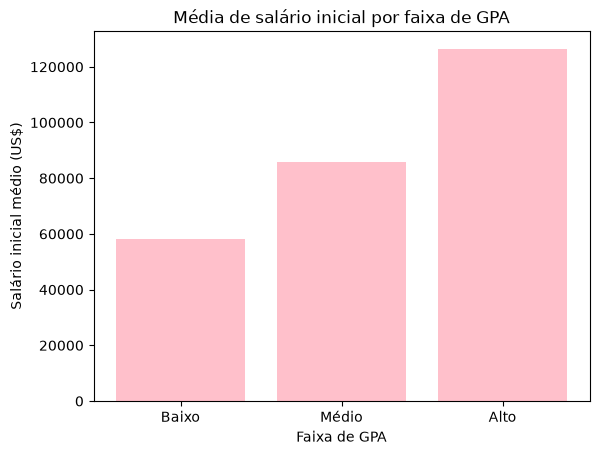

In [21]:
# gráfico de barras: salário inicial médio por faixa de GPA
plt.bar(df_med_gpa.index, df_med_gpa["Starting_Salary"], color="pink")
plt.title("Média de salário inicial por faixa de GPA")
plt.xlabel("Faixa de GPA")
plt.ylabel("Salário inicial médio (US$)")
plt.show()

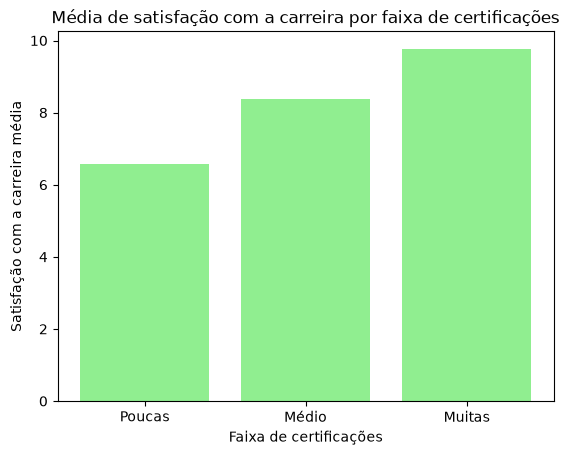

In [22]:
# gráfico de barras: satisfação com a carreira média por faixa de certificações
plt.bar(df_med_certificacoes.index, df_med_certificacoes["Career_Satisfaction"], color="lightgreen")
plt.title("Média de satisfação com a carreira por faixa de certificações")
plt.xlabel("Faixa de certificações")
plt.ylabel("Satisfação com a carreira média")
plt.show()